# Supervisor follow-up, Friday

Four items raised on Thursday.

| # | raised by | item |
|---|---|---|
| 1 | Mauricio | Is class specificity destroyed, or relocated into the hotspot |
| 2 | Shelley | Diff-CAM normalisation may be dominated by background |
| 3 | both | Per-label case studies, which structure does the heat land on |
| 4 | Mauricio | Push alignment to failure, report F1 as well as AUC |

Section 1 below.

**The challenge.** At alpha=0 the two class maps differ but are dispersed and
score at chance against the annotations. At alpha=5 they look alike. Mauricio's
alternative reading is that the information is now contained inside the
hotspot, so the map has become specific to where it should be rather than
losing class specificity.

**The test.** The current correlation uses all 196 patches. Most are empty
background where both maps sit near zero, which inflates agreement.
Restricting to lesion patches removes that. If the maps still correlate at
0.97 inside the lesion, the objection does not hold. If the correlation
drops, it does.

In [ ]:
# =============================================================================
# Setup. Self contained, duplicated from notebook 14 so this runs alone.
# =============================================================================
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import cv2
import torch
import torchvision.transforms as T
import matplotlib as mpl
import matplotlib.pyplot as plt
from PIL import Image
from scipy.stats import spearmanr, wilcoxon


def find_repo_root() -> Path:
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "scripts" / "generate_finer_cam_panderm.py").exists():
            return p.resolve()
    raise FileNotFoundError


REPO = find_repo_root()
for extra in [REPO, REPO / "external" / "PanDerm" / "classification"]:
    if str(extra) not in sys.path:
        sys.path.insert(0, str(extra))

from src.eval.cam_eval_utils import (
    mask_to_cam_grid_geom, transform_mask, transform_rgb,
    norm01, CAM_GRID, CROP_SIZE)

from run_class_finetuning_ha import (
    build_attention_gradcam_map, _unwrap_model, unpack_model_outputs)
from scripts.generate_finer_cam_panderm import (
    build_panderm_model, remap_official_finetune_checkpoint_keys,
    extract_checkpoint_state_dict, infer_panderm_variant_from_state_dict,
    infer_checkpoint_pooling)

# ---- switches -------------------------------------------------------------
GEOMETRY = "squash224"
POOLING  = "cls"
POOL_TAG = "gap" if POOLING == "mean" else "cls"
BLOCK    = -1
TOP_K    = 20
MEL_IDX, NV_IDX = 0, 1
CLASSES  = ["MEL", "NV"]
ALPHAS   = ["ha0", "ha3", "ha5"]
AV       = {"ha0": 0, "ha3": 3, "ha5": 5}

HAM_ROOT  = REPO / "data" / "HAM10000"
CKPT_DIR  = REPO / "external" / "checkpoints5"
EVAL_ROOT = REPO / "outputs" / "mel_nv" / "eval_cams" / POOL_TAG / GEOMETRY
QC_CSV    = REPO / "results" / "annotation_qc" / GEOMETRY / "annotation_qc_manifest.csv"
OUT       = REPO / "results" / "followup" / POOL_TAG
OUT.mkdir(parents=True, exist_ok=True)

DEVICE = ("mps" if torch.backends.mps.is_available()
          else "cuda" if torch.cuda.is_available() else "cpu")

C_ATTN, C_ACT, C_MEL = "#1F77B4", "#7F3F98", "#C62828"
mpl.rcParams.update({"figure.dpi": 130, "savefig.dpi": 300,
                     "savefig.bbox": "tight", "font.size": 9,
                     "axes.spines.top": False, "axes.spines.right": False})

PREPROCESS = T.Compose([
    T.Resize((CROP_SIZE, CROP_SIZE), interpolation=T.InterpolationMode.BILINEAR),
    T.ToTensor(),
    T.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
])

eval_df = pd.read_csv(EVAL_ROOT / "eval_images.csv")
qcp     = pd.read_csv(QC_CSV).query("qc_pass")
pred    = pd.read_csv(EVAL_ROOT / "predictions.csv")

_cache = {}


def load_model(ck):
    key = (POOL_TAG, ck)
    if key in _cache:
        return _cache[key]
    p = CKPT_DIR / f"checkpoint-best-{POOL_TAG}-{ck}.pth"
    raw, _ = extract_checkpoint_state_dict(
        torch.load(p, map_location="cpu", weights_only=False))
    st = remap_official_finetune_checkpoint_keys(raw)
    m = build_panderm_model(num_classes=2,
                            variant=infer_panderm_variant_from_state_dict(st),
                            use_mean_pooling=(POOLING == "mean"))
    miss, unexp = m.load_state_dict(st, strict=False)
    bad = [k for k in list(miss) + list(unexp)
           if k.startswith(("norm.", "fc_norm.", "head."))]
    if bad:
        raise RuntimeError(f"{ck}: critical keys {bad}")
    m.to(DEVICE).eval()
    for q in m.parameters():
        q.requires_grad_(True)
    _cache[key] = m
    return m


def load_tensor(rel):
    img = Image.open((HAM_ROOT / str(rel)).resolve()).convert("RGB")
    return PREPROCESS(img).unsqueeze(0).to(DEVICE)


def class_cams(model, x):
    """Both class attention CAMs from one forward. 14x14 each."""
    base = _unwrap_model(model)
    base.clear_xai_state()
    with torch.enable_grad():
        out = model(x, return_patch_tokens=True, store_attn=True,
                    attn_layer=BLOCK)
        logits, _ = unpack_model_outputs(out)
        cams = []
        for idx in (MEL_IDX, NV_IDX):
            t = torch.full((1,), idx, device=logits.device, dtype=torch.long)
            cams.append(build_attention_gradcam_map(
                model, logits, t, create_graph=False).detach())
    base.clear_xai_state()
    g = lambda c: c[0].float().cpu().numpy()
    return g(cams[0]), g(cams[1])


def topk_mask(cam, k):
    f = np.asarray(cam, np.float32).ravel()
    k = max(1, min(int(k), f.size))
    o = np.zeros(f.size, bool)
    o[np.argpartition(-f, k - 1)[:k]] = True
    return o.reshape(cam.shape)


# lesion masks at grid resolution
LESION = {}
for _, r in eval_df.iterrows():
    m = np.array(Image.open((HAM_ROOT / str(r.mask_rel_path)).resolve())
                 .convert("L")) > 127
    LESION[r.image_id] = mask_to_cam_grid_geom(m, GEOMETRY) >= 0.5

la = pd.Series({k: v.mean() for k, v in LESION.items()})
print(f"geometry {GEOMETRY}   pooling {POOL_TAG}   device {DEVICE}")
print(f"images {len(eval_df)}")
print(f"lesion coverage at {CAM_GRID}x{CAM_GRID}: "
      f"median {la.median():.3f}, range {la.min():.3f} to {la.max():.3f}")

geometry squash224   pooling gap   device mps
images 34
lesion coverage at 14x14: median 0.250, range 0.056 to 0.658


In [2]:
# =============================================================================
# SECTION 1. Is class specificity destroyed, or relocated inside the hotspot.
#
# Mauricio's objection. At alpha=0 the maps differ but are dispersed and score
# at chance. At alpha=5 they look alike, but the information may now sit inside
# the hotspot, so the map is specific to where it should be.
#
# Three measurements per image, per alpha.
#   global      correlation over all 196 patches, what we reported before
#   in-lesion   correlation over lesion patches only
#   in-hotspot  correlation over the union of both maps' top-k patches
#
# The third is the most direct answer. It asks whether the two maps differ
# WHERE THEY ARE BOTH HOT, which is exactly what Mauricio proposed.
#
# Also recorded: what fraction of each map's mass lies inside the lesion.
# If that rises with alpha, the maps really did become concentrated.
#
# READ
#   in-lesion correlation stays near 0.97   -> no relocation, our claim holds
#   in-lesion correlation drops well below  -> Mauricio is right, the global
#                                              number was inflated by empty
#                                              background
# =============================================================================
rows = []
for ck in ALPHAS:
    mdl = load_model(ck)
    for _, r in eval_df.iterrows():
        x = load_tensor(r.image_rel_path)
        cm, cn = class_cams(mdl, x)
        les = LESION[r.image_id]
        nm, nn = norm01(cm), norm01(cn)

        # global, all 196 patches
        g_r = float(np.corrcoef(nm.ravel(), nn.ravel())[0, 1])
        ma, mb = topk_mask(nm, TOP_K), topk_mask(nn, TOP_K)
        g_iou = float((ma & mb).sum() / ((ma | mb).sum() + 1e-8))

        # in lesion only, top-k scaled to lesion size
        n_in = int(les.sum())
        if n_in >= 8:
            a_in, b_in = nm[les], nn[les]
            l_r = (float(np.corrcoef(a_in, b_in)[0, 1])
                   if a_in.std() > 1e-8 and b_in.std() > 1e-8 else np.nan)
            k_in = max(2, int(round(0.10 * n_in)))
            sa = np.zeros(n_in, bool); sa[np.argpartition(-a_in, k_in - 1)[:k_in]] = True
            sb = np.zeros(n_in, bool); sb[np.argpartition(-b_in, k_in - 1)[:k_in]] = True
            l_iou = float((sa & sb).sum() / ((sa | sb).sum() + 1e-8))
        else:
            l_r, l_iou, k_in = np.nan, np.nan, 0

        # inside the hotspot, union of both maps' top-k
        hot = ma | mb
        if hot.sum() >= 8:
            a_h, b_h = nm[hot], nn[hot]
            h_r = (float(np.corrcoef(a_h, b_h)[0, 1])
                   if a_h.std() > 1e-8 and b_h.std() > 1e-8 else np.nan)
        else:
            h_r = np.nan

        rows.append({
            "ckpt": ck, "alpha": AV[ck], "image_id": r.image_id,
            "gt_label": r.gt_label,
            "r_global": g_r, "r_lesion": l_r, "r_hotspot": h_r,
            "iou_global": g_iou, "iou_lesion": l_iou,
            "lesion_patches": n_in, "k_in_lesion": k_in,
            "mass_in_lesion_mel": float(nm[les].sum() / (nm.sum() + 1e-8)),
            "mass_in_lesion_nv":  float(nn[les].sum() / (nn.sum() + 1e-8)),
            "lesion_area_frac": float(les.mean()),
        })
    print(f"  done {ck}")

S1 = pd.DataFrame(rows)
S1["pooling"] = POOL_TAG
S1.to_csv(OUT / "s1_conditioned_class_correlation.csv", index=False)

print("\n" + "=" * 82)
print("SECTION 1  class map correlation, three scopes")
print("=" * 82)
print(S1.groupby("ckpt")[["r_global", "r_lesion", "r_hotspot",
                          "iou_global", "iou_lesion",
                          "mass_in_lesion_mel", "mass_in_lesion_nv"]]
      .median().reindex(ALPHAS).round(3).to_string())

print("\nchange from alpha 0 to alpha 5")
a0 = S1[S1.ckpt == "ha0"].set_index("image_id")
a5 = S1[S1.ckpt == "ha5"].set_index("image_id")
for col, nm_ in [("r_global", "correlation, all patches"),
                 ("r_lesion", "correlation, in lesion"),
                 ("r_hotspot", "correlation, in hotspot"),
                 ("mass_in_lesion_mel", "CAM mass inside lesion")]:
    d = (a5[col] - a0[col]).dropna()
    if len(d) < 5:
        continue
    stat, p = wilcoxon(a5[col].dropna(), a0[col].reindex(a5[col].dropna().index))
    print(f"  {nm_:28} {a0[col].median():+.3f} -> {a5[col].median():+.3f}"
          f"   diff {d.median():+.3f}   p {p:.2e}   n {len(d)}")

print("\n" + "-" * 82)
lr5 = S1[S1.ckpt == "ha5"].r_lesion.median()
gr5 = S1[S1.ckpt == "ha5"].r_global.median()
if lr5 > 0.85:
    print("VERDICT. The maps remain near identical INSIDE the lesion")
    print(f"        (r = {lr5:.3f} versus {gr5:.3f} globally). The collapse is")
    print("        not an artifact of agreeing on empty background.")
elif lr5 < 0.5:
    print("VERDICT. The maps DO differ inside the lesion")
    print(f"        (r = {lr5:.3f} versus {gr5:.3f} globally). The global")
    print("        correlation was inflated by background agreement.")
    print("        Mauricio is right. Restate the E4 claim.")
else:
    print(f"VERDICT. Partial. In lesion r = {lr5:.3f} versus {gr5:.3f} global.")
    print("        Some class signal survives inside the lesion but it is weak.")

  done ha0
  done ha3
  done ha5

SECTION 1  class map correlation, three scopes
      r_global  r_lesion  r_hotspot  iou_global  iou_lesion  mass_in_lesion_mel  mass_in_lesion_nv
ckpt                                                                                              
ha0     -0.241    -0.327     -0.725       0.000       0.000               0.517              0.205
ha3      0.969     0.858      0.090       0.538       0.261               0.838              0.871
ha5      0.970     0.900      0.023       0.455       0.200               0.851              0.879

change from alpha 0 to alpha 5
  correlation, all patches     -0.241 -> +0.970   diff +1.195   p 1.16e-10   n 34
  correlation, in lesion       -0.327 -> +0.900   diff +1.189   p nan   n 32
  correlation, in hotspot      -0.725 -> +0.023   diff +0.788   p 1.16e-10   n 34
  CAM mass inside lesion       +0.517 -> +0.851   diff +0.330   p 1.16e-10   n 34

--------------------------------------------------------------------

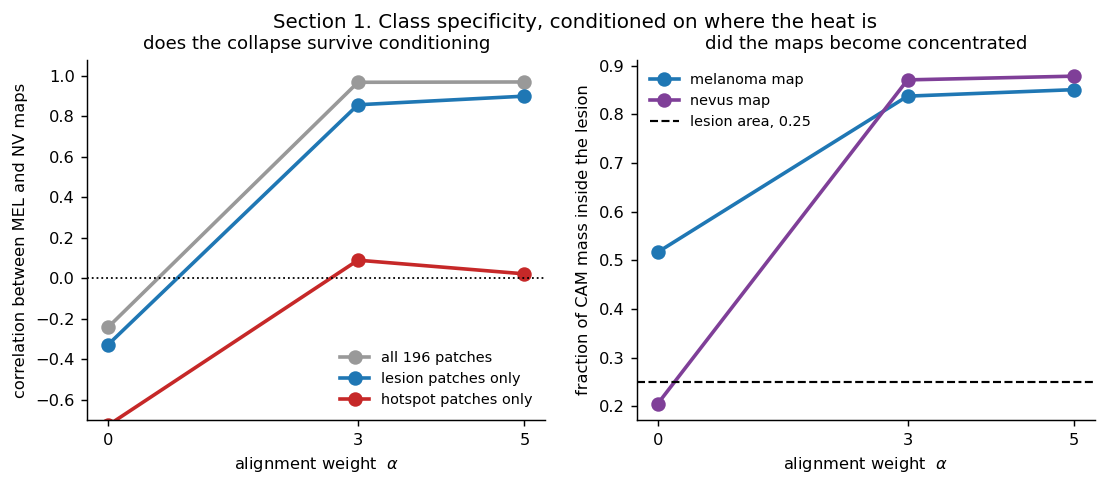

In [3]:
# =============================================================================
# FIGURE. The three scopes side by side.
#
# READ  left   if the in lesion line tracks the global line, the collapse is
#              real. If it stays low, the global number was inflated.
#       right  CAM mass inside the lesion. Rising confirms the maps did
#              become concentrated, which is Mauricio's premise. The question
#              is whether they also became class specific.
# =============================================================================
fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))

for col, col_c, nm_ in [("r_global", "#999999", "all 196 patches"),
                        ("r_lesion", C_ATTN, "lesion patches only"),
                        ("r_hotspot", C_MEL, "hotspot patches only")]:
    m = S1.groupby("ckpt")[col].median().reindex(ALPHAS)
    ax[0].plot([AV[c] for c in ALPHAS], m.values, "o-",
               color=col_c, lw=2, ms=7, label=nm_)

ax[0].axhline(0, color="k", ls=":", lw=1)
ax[0].set_xticks([0, 3, 5])
ax[0].set_xlabel(r"alignment weight  $\alpha$")
ax[0].set_ylabel("correlation between MEL and NV maps")
ax[0].set_ylim(-0.7, 1.08)
ax[0].legend(frameon=False, fontsize=8, loc="lower right")
ax[0].set_title("does the collapse survive conditioning", fontsize=10)

for col, col_c, nm_ in [("mass_in_lesion_mel", C_ATTN, "melanoma map"),
                        ("mass_in_lesion_nv", C_ACT, "nevus map")]:
    m = S1.groupby("ckpt")[col].median().reindex(ALPHAS)
    ax[1].plot([AV[c] for c in ALPHAS], m.values, "o-",
               color=col_c, lw=2, ms=7, label=nm_)

la_med = S1.groupby("ckpt").lesion_area_frac.median().iloc[0]
ax[1].axhline(la_med, color="k", ls="--", lw=1.2,
              label=f"lesion area, {la_med:.2f}")
ax[1].set_xticks([0, 3, 5])
ax[1].set_xlabel(r"alignment weight  $\alpha$")
ax[1].set_ylabel("fraction of CAM mass inside the lesion")
ax[1].legend(frameon=False, fontsize=8)
ax[1].set_title("did the maps become concentrated", fontsize=10)

fig.suptitle("Section 1. Class specificity, conditioned on where the heat is",
             fontsize=11)
fig.savefig(OUT / "s1_conditioned_correlation.png")
plt.show()

In [4]:
# =============================================================================
# SECTION 1b. Fixes and three additional tests.
#
#   1  paired test with proper NaN handling
#   2  chance baseline for the IoU columns, so global and in lesion compare
#   3  Spearman inside the lesion, rank based so it resists the range
#      restriction that makes r_hotspot hard to read
#   4  is the alpha=0 nevus map below chance on the lesion
# =============================================================================
from scipy.stats import wilcoxon, spearmanr

def paired(df, col, a, b):
    """Wilcoxon on complete pairs only."""
    p = (df.pivot_table(index="image_id", columns="ckpt", values=col)
           .reindex(columns=[a, b]).dropna())
    if len(p) < 5:
        return None
    d = (p[a] - p[b]).to_numpy()
    if not np.any(d != 0):
        return {"n": len(p), "diff": 0.0, "p": 1.0, "wins": 0, "losses": 0}
    _, pv = wilcoxon(p[a], p[b])
    return {"n": len(p), "diff": float(np.median(d)), "p": float(pv),
            "wins": int((d > 0).sum()), "losses": int((d < 0).sum())}


print("=" * 78)
print("1. PAIRED TESTS, alpha 5 versus alpha 0")
print("=" * 78)
for col, nm_ in [("r_global", "correlation, all patches"),
                 ("r_lesion", "correlation, in lesion"),
                 ("r_hotspot", "correlation, in hotspot"),
                 ("iou_global", "top-k overlap, all patches"),
                 ("iou_lesion", "top-k overlap, in lesion"),
                 ("mass_in_lesion_mel", "MEL mass inside lesion"),
                 ("mass_in_lesion_nv", "NV mass inside lesion")]:
    r = paired(S1, col, "ha5", "ha0")
    if r:
        print(f"  {nm_:30} {r['diff']:+.3f}   p {r['p']:.2e}   "
              f"n {r['n']}   ({r['wins']}/{r['losses']})")


print("\n" + "=" * 78)
print("2. IOU AGAINST CHANCE")
print("=" * 78)
print("  for two random sets of size k drawn from n, expected IoU is k/(2n-k)")

ch_g = TOP_K / (2 * CAM_GRID ** 2 - TOP_K)
kl = S1[S1.k_in_lesion > 0].k_in_lesion.median()
nl = S1[S1.k_in_lesion > 0].lesion_patches.median()
ch_l = kl / (2 * nl - kl)

print(f"\n  global     k={TOP_K}  n={CAM_GRID**2}   chance {ch_g:.3f}")
print(f"  in lesion  k={kl:.0f}   n={nl:.0f}    chance {ch_l:.3f}")
print(f"\n  {'':10} {'observed':>10} {'chance':>8} {'lift':>8}")
for ck in ALPHAS:
    g = S1[S1.ckpt == ck].iou_global.median()
    l = S1[S1.ckpt == ck].iou_lesion.median()
    print(f"  {ck:10} {g:10.3f} {ch_g:8.3f} {g/ch_g:7.1f}x   global")
    print(f"  {'':10} {l:10.3f} {ch_l:8.3f} {l/ch_l:7.1f}x   in lesion")


print("\n" + "=" * 78)
print("3. SPEARMAN INSIDE THE LESION")
print("=" * 78)
print("  rank based, so it resists the range restriction that compresses")
print("  Pearson when you select only high values")

rows = []
for ck in ALPHAS:
    mdl = load_model(ck)
    for _, r in eval_df.iterrows():
        les = LESION[r.image_id]
        if les.sum() < 8:
            continue
        cm, cn = class_cams(mdl, load_tensor(r.image_rel_path))
        a, b = norm01(cm)[les], norm01(cn)[les]
        rows.append({"ckpt": ck, "image_id": r.image_id,
                     "spearman_lesion": float(spearmanr(a, b).statistic)})

SP = pd.DataFrame(rows)
print()
print(SP.groupby("ckpt").spearman_lesion
      .agg(n="count", median="median").reindex(ALPHAS).round(3).to_string())


print("\n" + "=" * 78)
print("4. IS THE ALPHA=0 NEVUS MAP BELOW CHANCE ON THE LESION")
print("=" * 78)
print("  if CAM mass inside the lesion is below the lesion area fraction,")
print("  the map is anti concentrated, it prefers background")

for ck in ALPHAS:
    s = S1[S1.ckpt == ck]
    for col, nm_ in [("mass_in_lesion_mel", "MEL"),
                     ("mass_in_lesion_nv", " NV")]:
        d = s[col] - s.lesion_area_frac
        _, pv = wilcoxon(s[col], s.lesion_area_frac)
        tag = "BELOW chance" if d.median() < 0 else "above chance"
        print(f"  {ck}  {nm_}  mass {s[col].median():.3f}  "
              f"area {s.lesion_area_frac.median():.3f}  "
              f"diff {d.median():+.3f}  p {pv:.2e}   {tag}")

S1.merge(SP, on=["ckpt", "image_id"], how="left") \
  .to_csv(OUT / "s1_conditioned_class_correlation.csv", index=False)

print("\n" + "-" * 78)
n0 = S1[S1.ckpt == "ha0"]
print(f"""SYNTHESIS

At alpha=0 the nevus map places {n0.mass_in_lesion_nv.median():.3f} of its mass
inside a lesion covering {n0.lesion_area_frac.median():.3f} of the frame. Below chance.
The melanoma map places {n0.mass_in_lesion_mel.median():.3f}, roughly twice chance.
So the anti correlation at alpha=0 is one map on the lesion and one on
background, not two competing hypotheses about the lesion.

At alpha=5 both maps place about 0.85 of their mass inside the lesion and
correlate at {S1[S1.ckpt=='ha5'].r_lesion.median():.3f} there. Peak agreement inside the lesion is
{S1[S1.ckpt=='ha5'].iou_lesion.median()/ch_l:.1f}x chance versus {S1[S1.ckpt=='ha5'].iou_global.median()/ch_g:.1f}x globally, so a weak residual
distinction survives.

Neither state gives a usable class discriminative explanation.""")

1. PAIRED TESTS, alpha 5 versus alpha 0
  correlation, all patches       +1.195   p 1.16e-10   n 34   (34/0)
  correlation, in lesion         +1.189   p 4.66e-10   n 32   (32/0)
  correlation, in hotspot        +0.788   p 1.16e-10   n 34   (34/0)
  top-k overlap, all patches     +0.429   p 3.53e-07   n 34   (34/0)
  top-k overlap, in lesion       +0.188   p 3.39e-05   n 34   (27/1)
  MEL mass inside lesion         +0.330   p 1.16e-10   n 34   (34/0)
  NV mass inside lesion          +0.687   p 1.16e-10   n 34   (34/0)

2. IOU AGAINST CHANCE
  for two random sets of size k drawn from n, expected IoU is k/(2n-k)

  global     k=20  n=196   chance 0.054
  in lesion  k=5   n=49    chance 0.054

               observed   chance     lift
  ha0             0.000    0.054     0.0x   global
                  0.000    0.054     0.0x   in lesion
  ha3             0.538    0.054    10.0x   global
                  0.261    0.054     4.9x   in lesion
  ha5             0.455    0.054     8.5x   globa

/var/folders/8q/87zqgq3546j682gq4dl7t0b00000gn/T/ipykernel_45209/3751947213.py:78: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  "spearman_lesion": float(spearmanr(a, b).statistic)})



       n  median
ckpt            
ha0   32  -0.481
ha3   34   0.743
ha5   34   0.748

4. IS THE ALPHA=0 NEVUS MAP BELOW CHANCE ON THE LESION
  if CAM mass inside the lesion is below the lesion area fraction,
  the map is anti concentrated, it prefers background
  ha0  MEL  mass 0.517  area 0.250  diff +0.110  p 3.85e-05   above chance
  ha0   NV  mass 0.205  area 0.250  diff -0.059  p 1.53e-02   BELOW chance
  ha3  MEL  mass 0.838  area 0.250  diff +0.531  p 1.16e-10   above chance
  ha3   NV  mass 0.871  area 0.250  diff +0.598  p 1.16e-10   above chance
  ha5  MEL  mass 0.851  area 0.250  diff +0.555  p 1.16e-10   above chance
  ha5   NV  mass 0.879  area 0.250  diff +0.609  p 1.16e-10   above chance

------------------------------------------------------------------------------
SYNTHESIS

At alpha=0 the nevus map places 0.205 of its mass
inside a lesion covering 0.250 of the frame. Below chance.
The melanoma map places 0.517, roughly twice chance.
So the anti correlation at alpha=0

---
## Section 2. Diff-CAM, renormalised inside the lesion

**Shelley's objection.** The difference may be genuinely inside the lesion,
but the global normalisation is dominated by activations outside it. Since
`diff = max(0, cam_A - cam_B)` is then divided by its global maximum, a
large off-lesion difference crushes the in-lesion signal toward zero.

**Her fix.** Restrict to the lesion first, then normalise.

**Three variants tested.**

| variant | procedure |
|---|---|
| global | current. difference over the whole grid, global max |
| lesion normalised | difference over the whole grid, renormalised on lesion patches |
| lesion restricted | both maps restricted to the lesion first, then differenced |

Each scored against the melanoma feature union, with a permutation null.

**Her caveat, recorded.** Annotations can legitimately fall outside the
lesion, for example vascular patterns. Masking is therefore a diagnostic
for whether the normalisation is the problem, not a universally correct
procedure.

In [5]:
# =============================================================================
# SECTION 2. Is Diff-CAM at chance, or is the normalisation hiding the signal.
#
# READ  if lesion normalised or lesion restricted moves clearly above the
#       null, Shelley is right and "does not work at all" must be retracted.
#       if all three sit at the null, the original claim stands.
# =============================================================================
from sklearn.metrics import roc_auc_score

CK = "ha5"
mdl = load_model(CK)


def mel_union_grid(image_id):
    sub = qcp[(qcp.Image_ID == image_id) & (qcp.label_group == "MEL")]
    if not len(sub):
        return None
    acc = None
    for _, r in sub.iterrows():
        m = np.array(Image.open(r.mask_path).convert("L")) > 127
        acc = m if acc is None else (acc | m)
    return mask_to_cam_grid_geom(acc, GEOMETRY) >= 0.5


UNION = {i: mel_union_grid(i) for i in eval_df.image_id}


def diff_variants(cm, cn, les):
    """Three constructions of the difference map, all 14x14 in [0,1]."""
    a, b = norm01(cm), norm01(cn)

    # 1. current. global difference, global normalisation
    d = np.clip(a - b, 0, None)
    v_global = d / (d.max() + 1e-8)

    # 2. Shelley's fix. same difference, renormalised on lesion patches
    v_lesnorm = np.zeros_like(d)
    if les.sum() >= 4 and d[les].max() > 1e-8:
        v_lesnorm[les] = d[les] / d[les].max()

    # 3. stronger. restrict both maps first, then difference
    v_lesres = np.zeros_like(d)
    if les.sum() >= 4:
        ai, bi = a[les], b[les]
        ai = (ai - ai.min()) / (ai.max() - ai.min() + 1e-8)
        bi = (bi - bi.min()) / (bi.max() - bi.min() + 1e-8)
        di = np.clip(ai - bi, 0, None)
        v_lesres[les] = di / (di.max() + 1e-8)

    return {"global": v_global, "lesion_norm": v_lesnorm,
            "lesion_restricted": v_lesres}


# ---- collect all maps once -------------------------------------------------
store, rows = {}, []
for _, r in eval_df.iterrows():
    un = UNION.get(r.image_id)
    les = LESION[r.image_id]
    if un is None or un.sum() == 0 or un.all() or les.sum() < 4:
        continue

    cm, cn = class_cams(mdl, load_tensor(r.image_rel_path))
    dv = diff_variants(cm, cn, les)
    tgt = cm if r.gt_label == "MEL" else cn
    store[r.image_id] = {"un": un, "les": les,
                         "grad": norm01(tgt), **dv}

    row = {"image_id": r.image_id, "gt_label": r.gt_label,
           "gradcam_a": float(roc_auc_score(un.ravel(),
                                            norm01(tgt).ravel()))}
    for k, v in dv.items():
        row[k] = (float(roc_auc_score(un.ravel(), v.ravel()))
                  if v.max() > 1e-8 else np.nan)
        # how much of the difference mass sits outside the lesion
        row[f"{k}_outside"] = float(v[~les].sum() / (v.sum() + 1e-8))
    rows.append(row)

S2 = pd.DataFrame(rows)
S2.to_csv(OUT / "s2_diffcam_variants.csv", index=False)

# ---- permutation null ------------------------------------------------------
rng = np.random.default_rng(0)
ids = list(store)
null = {}
for k in ["gradcam_a", "global", "lesion_norm", "lesion_restricted"]:
    key = "grad" if k == "gradcam_a" else k
    vals = []
    for _ in range(600):
        i, j = rng.choice(len(ids), 2, replace=False)
        m_ = store[ids[i]][key]
        u_ = store[ids[j]]["un"]
        if m_.max() < 1e-8 or u_.sum() == 0 or u_.all():
            continue
        vals.append(roc_auc_score(u_.ravel(), m_.ravel()))
    null[k] = (float(np.mean(vals)), float(np.percentile(vals, 95)))

print("=" * 82)
print(f"SECTION 2  Diff-CAM variants against the MEL feature union, n={len(S2)}")
print("=" * 82)
print(f"{'variant':22} {'AUC':>8} {'null':>8} {'above':>8} "
      f"{'>p95':>6} {'mass out':>9}")
print("-" * 82)
for k, nm_ in [("gradcam_a", "Grad-CAM, reference"),
               ("global", "Diff, global norm"),
               ("lesion_norm", "Diff, lesion norm"),
               ("lesion_restricted", "Diff, lesion restricted")]:
    obs = S2[k].median()
    nm_mean, nm_p95 = null[k]
    out = S2[f"{k}_outside"].median() if k != "gradcam_a" else np.nan
    print(f"{nm_:22} {obs:8.3f} {nm_mean:8.3f} {obs - nm_mean:+8.3f} "
          f"{'yes' if obs > nm_p95 else 'no':>6} "
          f"{out:9.3f}" if k != "gradcam_a" else
          f"{nm_:22} {obs:8.3f} {nm_mean:8.3f} {obs - nm_mean:+8.3f} "
          f"{'yes' if obs > nm_p95 else 'no':>6} {'':>9}")

print("\npaired against the global variant")
for k, nm_ in [("lesion_norm", "lesion norm"),
               ("lesion_restricted", "lesion restricted")]:
    p = S2[["global", k]].dropna()
    if len(p) < 5:
        continue
    d = (p[k] - p["global"]).to_numpy()
    if np.any(d != 0):
        _, pv = wilcoxon(p[k], p["global"])
        print(f"  {nm_:20} {np.median(d):+.3f}   p {pv:.2e}   "
              f"({int((d > 0).sum())}/{int((d < 0).sum())})")

best = max(["global", "lesion_norm", "lesion_restricted"],
           key=lambda k: S2[k].median() - null[k][0])
bm = S2[best].median() - null[best][0]

print("\n" + "-" * 82)
if bm > 0.05 and S2[best].median() > null[best][1]:
    print(f"VERDICT. Shelley is right. The '{best}' variant reaches")
    print(f"        {S2[best].median():.3f}, which is {bm:+.3f} above its null and")
    print(f"        clears the 95th percentile. Retract 'does not work at all'.")
elif bm > 0.02:
    print(f"VERDICT. Partial. '{best}' improves on the global variant but")
    print(f"        the margin is only {bm:+.3f} and it does not clear p95.")
else:
    print(f"VERDICT. All three variants sit at their null. The original claim")
    print(f"        stands. Best margin {bm:+.3f} from '{best}'.")
    print(f"        The difference carries no image specific information")
    print(f"        regardless of normalisation.")

SECTION 2  Diff-CAM variants against the MEL feature union, n=31
variant                     AUC     null    above   >p95  mass out
----------------------------------------------------------------------------------
Grad-CAM, reference       0.965    0.863   +0.102    yes          
Diff, global norm         0.606    0.608   -0.002     no     0.499
Diff, lesion norm         0.667    0.646   +0.021     no     0.000
Diff, lesion restricted    0.681    0.628   +0.053     no     0.000

paired against the global variant
  lesion norm          +0.082   p 5.61e-06   (27/0)
  lesion restricted    +0.059   p 8.69e-05   (25/4)

----------------------------------------------------------------------------------
VERDICT. Partial. 'lesion_restricted' improves on the global variant but
        the margin is only +0.053 and it does not clear p95.


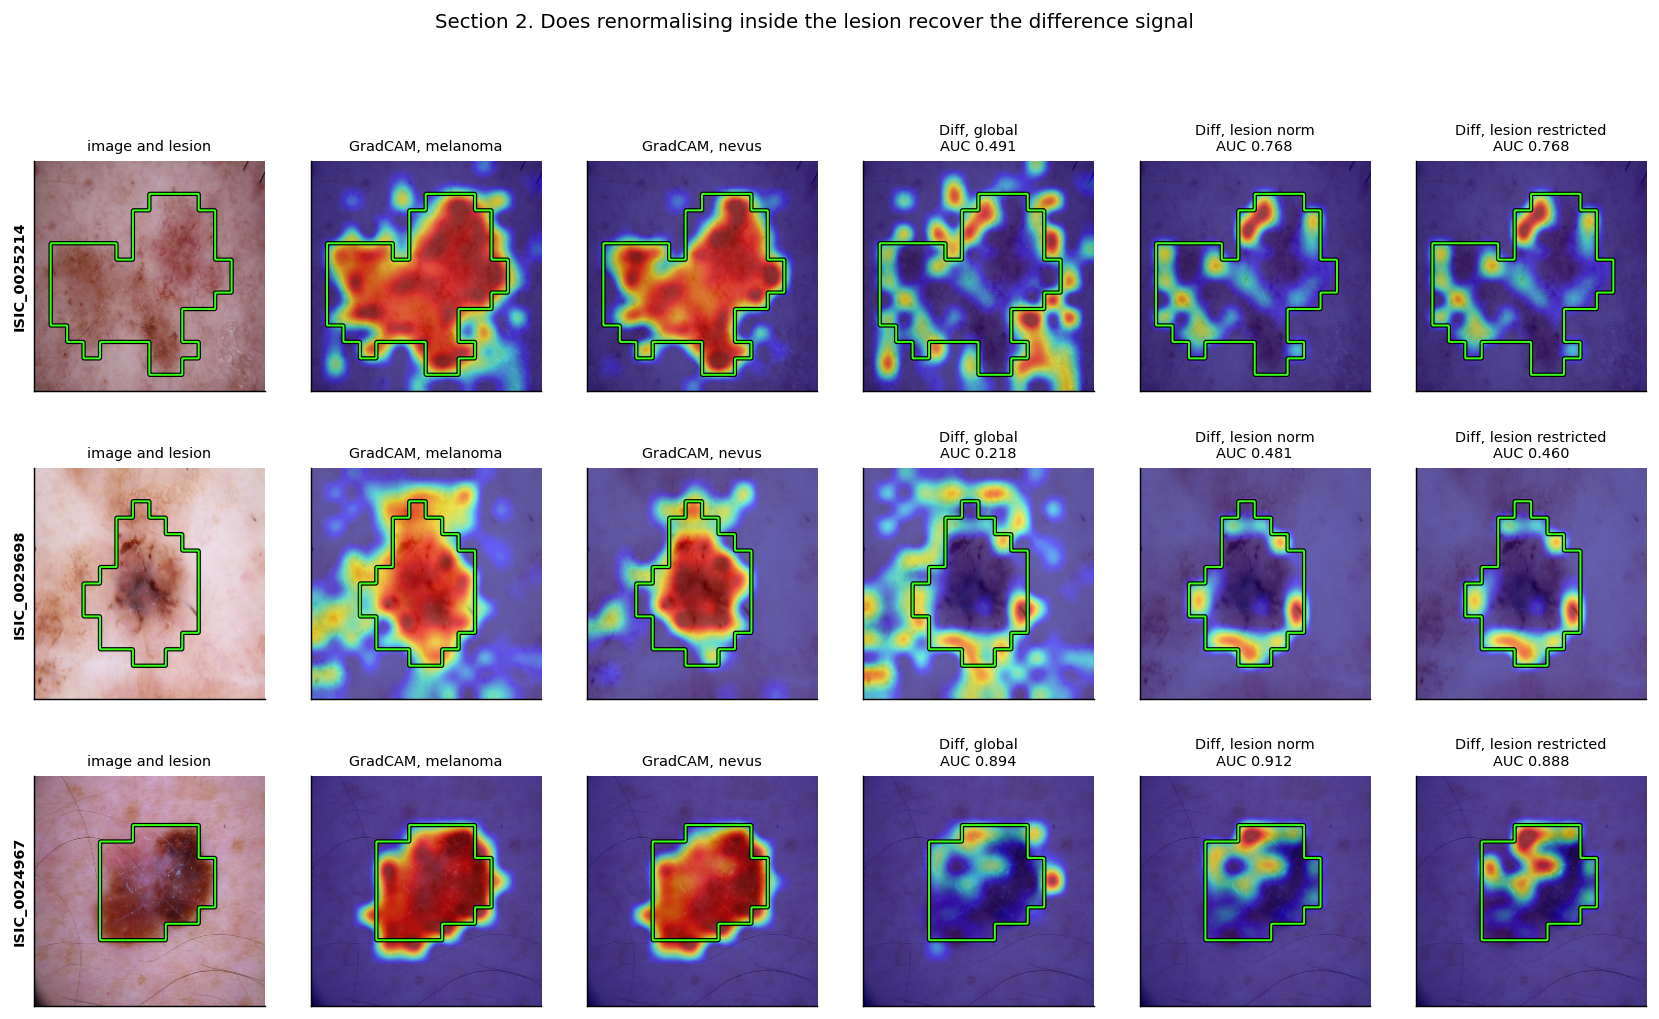

    image_id gt_label  gradcam_a  global  lesion_norm  lesion_restricted  global_outside  lesion_norm_outside
ISIC_0024756      MEL      0.978   0.594        0.654              0.681           0.818                  0.0
ISIC_0024886      MEL      0.977   0.620        0.665              0.665           0.776                  0.0
ISIC_0024967      MEL      0.991   0.894        0.912              0.888           0.263                  0.0
ISIC_0025132      MEL      0.912   0.546        0.635              0.536           0.697                  0.0
ISIC_0025214       NV      0.941   0.491        0.768              0.768           0.655                  0.0
ISIC_0026491       NV      0.966   0.267        0.488              0.488           0.767                  0.0
ISIC_0026582       NV      0.996   0.602        0.602              0.602           0.000                  0.0
ISIC_0026584       NV      0.992   0.647        0.791              0.791           0.458                  0.0
ISIC_00267

In [6]:
# =============================================================================
# FIGURE. The case Mauricio pointed at, all three variants.
#
# READ  if the lesion normalised panel shows structure the global panel does
#       not, the normalisation was hiding it. If both look like noise, the
#       difference genuinely carries nothing.
# =============================================================================
S2["gain"] = S2.lesion_norm - S2["global"]
SHOW = list(S2.nlargest(2, "gain").image_id) + \
       list(S2[S2.gt_label == "MEL"].nlargest(1, "gradcam_a").image_id)
SHOW = list(dict.fromkeys(SHOW))[:3]

fig, axes = plt.subplots(len(SHOW), 6, figsize=(16, 2.9 * len(SHOW)))
axes = np.atleast_2d(axes)

for i, iid in enumerate(SHOW):
    r = eval_df.set_index("image_id").loc[iid]
    rgb = transform_rgb(np.array(Image.open(
        (HAM_ROOT / str(r.image_rel_path)).resolve()).convert("RGB")), GEOMETRY)
    cm, cn = class_cams(mdl, load_tensor(r.image_rel_path))
    les = LESION[iid]
    dv = diff_variants(cm, cn, les)

    les224 = cv2.resize(les.astype(np.float32), (CROP_SIZE, CROP_SIZE),
                        interpolation=cv2.INTER_NEAREST)

    def draw(ax, cam, title):
        ax.imshow(rgb)
        if cam is not None and cam.max() > 1e-8:
            up = cv2.resize(norm01(cam), (CROP_SIZE, CROP_SIZE),
                            interpolation=cv2.INTER_CUBIC)
            ax.imshow(up, cmap="jet", alpha=0.58, vmin=0, vmax=1)
        ax.contour(les224, [0.5], colors="black", linewidths=2.4)
        ax.contour(les224, [0.5], colors="#39FF14", linewidths=1.1)
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_title(title, fontsize=8)

    row = S2[S2.image_id == iid].iloc[0]
    draw(axes[i, 0], None, "image and lesion")
    draw(axes[i, 1], cm, "GradCAM, melanoma")
    draw(axes[i, 2], cn, "GradCAM, nevus")
    draw(axes[i, 3], dv["global"], f"Diff, global\nAUC {row['global']:.3f}")
    draw(axes[i, 4], dv["lesion_norm"],
         f"Diff, lesion norm\nAUC {row['lesion_norm']:.3f}")
    draw(axes[i, 5], dv["lesion_restricted"],
         f"Diff, lesion restricted\nAUC {row['lesion_restricted']:.3f}")
    axes[i, 0].set_ylabel(iid, fontsize=8, fontweight="bold")

fig.suptitle("Section 2. Does renormalising inside the lesion recover the "
             "difference signal", fontsize=11, y=1.00)
fig.savefig(OUT / "s2_diffcam_variants.png")
plt.show()

print(S2[["image_id", "gt_label", "gradcam_a", "global",
          "lesion_norm", "lesion_restricted",
          "global_outside", "lesion_norm_outside"]]
      .round(3).to_string(index=False))

---
## Section 3. Which structure does the heat land on

**The request.** On images carrying several distinct labels, which one does
the heat actually select. Not group level, label level.

**Two questions per image.**

| question | metric |
|---|---|
| did the model reach this structure | coverage, corrected for size |
| where did the heat actually go | share of top-k mass per label |

The second is the one they asked for. It attributes the heat across the
labels present, so the shares sum to at most one.

**Caveat.** Labels overlap spatially, so a patch can belong to two. Shares
are therefore not exclusive and the analysis is descriptive.

In [7]:
# =============================================================================
# SECTION 3. Heat attribution across labels, per image.
#
# For every image with at least two distinct labels, split the top-k CAM
# mass across the labels present.
#
# READ  share      what fraction of the heat landed on this label
#       coverage   what fraction of this label the heat reached
#       cov_norm   coverage corrected for the size budget
#       unassigned heat landing on no annotated structure
# =============================================================================
CAM_TYPES = {"gradcam_a": "Grad-CAM", "finercam": "Finer-CAM"}
ACT_DIR = EVAL_ROOT / f"act__{CK}__g0p6"


def load_act(image_id, kind):
    f = ACT_DIR / "raw_cams" / f"{image_id}_{kind}.npy"
    if not f.exists():
        return None
    a = np.load(f)
    return (cv2.resize(a.astype(np.float32), (CAM_GRID, CAM_GRID),
                       interpolation=cv2.INTER_AREA)
            if a.shape != (CAM_GRID, CAM_GRID) else a)


def label_grids(image_id):
    out = {}
    for _, r in qcp[qcp.Image_ID == image_id].iterrows():
        m = np.array(Image.open(r.mask_path).convert("L")) > 127
        g = mask_to_cam_grid_geom(m, GEOMETRY) >= 0.5
        if g.sum() == 0:
            continue
        out[r.label] = (g, r.label_group)
    return out


rows = []
for _, r in eval_df.iterrows():
    lg = label_grids(r.image_id)
    if len(lg) < 2:
        continue
    for kind, nm_ in CAM_TYPES.items():
        cam = load_act(r.image_id, kind)
        if cam is None:
            continue
        c = norm01(cam)
        sel = topk_mask(c, TOP_K)
        mass = c[sel].sum()

        covered = np.zeros_like(sel)
        for lab, (g, grp) in lg.items():
            hit = sel & g
            covered |= g
            n_t = int(g.sum())
            ceil = min(1.0, TOP_K / n_t)
            chance = TOP_K / c.size
            cov = hit.sum() / n_t
            rows.append({
                "image_id": r.image_id, "gt_label": r.gt_label,
                "cam": nm_, "label": lab, "label_group": grp,
                "patches": n_t,
                "share": float(c[hit].sum() / (mass + 1e-8)),
                "coverage": float(cov),
                "cov_norm": (float((cov - chance) / (ceil - chance))
                             if ceil - chance > 1e-6 else np.nan),
            })
        rows.append({
            "image_id": r.image_id, "gt_label": r.gt_label,
            "cam": nm_, "label": "UNASSIGNED", "label_group": "none",
            "patches": int((~covered).sum()),
            "share": float(c[sel & ~covered].sum() / (mass + 1e-8)),
            "coverage": np.nan, "cov_norm": np.nan,
        })

S3 = pd.DataFrame(rows)
S3.to_csv(OUT / "s3_label_attribution.csv", index=False)

print("=" * 78)
print(f"SECTION 3  heat attribution, {S3.image_id.nunique()} images with "
      f"two or more labels")
print("=" * 78)

for nm_ in CAM_TYPES.values():
    s = S3[(S3.cam == nm_) & (S3.label != "UNASSIGNED")]
    u = S3[(S3.cam == nm_) & (S3.label == "UNASSIGNED")]
    print(f"\n{nm_}")
    t = (s.groupby("label")
           .agg(n=("share", "size"), patches=("patches", "median"),
                share=("share", "median"), cov_norm=("cov_norm", "median"))
           .sort_values("share", ascending=False))
    print(t.round(3).to_string())
    print(f"  {'UNASSIGNED':40} {u.share.median():.3f} "
          f"of heat on no annotated structure")

print("\n\nwhich label wins the most heat, per image")
win = (S3[S3.label != "UNASSIGNED"]
       .sort_values("share", ascending=False)
       .groupby(["cam", "image_id"]).head(1))
for nm_ in CAM_TYPES.values():
    print(f"\n{nm_}")
    print(win[win.cam == nm_].label.value_counts().to_string())

print("\n\ndo the two CAMs pick the same winner")
w = win.pivot_table(index="image_id", columns="cam", values="label",
                    aggfunc="first").dropna()
agree = (w.iloc[:, 0] == w.iloc[:, 1]).sum()
print(f"  same label {agree} of {len(w)} images")
if agree < len(w):
    print(w[w.iloc[:, 0] != w.iloc[:, 1]].to_string())

SECTION 3  heat attribution, 33 images with two or more labels

Grad-CAM
                                                    n  patches  share  cov_norm
label                                                                          
regular_network                                     4     20.0  0.683     0.632
homogeneous                                         3     21.0  0.648     0.552
structureless_area                                 29     17.0  0.552     0.722
diagnostic_region                                   3      8.0  0.446     0.841
preminent_skin_markings                             3     10.0  0.316     0.555
atypical_vascular_pattern                           3      9.0  0.315     1.000
atypical_network                                   15     14.0  0.282     0.443
regression_scar_like_depigmentation_and_peppering   4     11.0  0.220     0.324
negative_network                                    1      4.0  0.196     1.000
peppering                                      

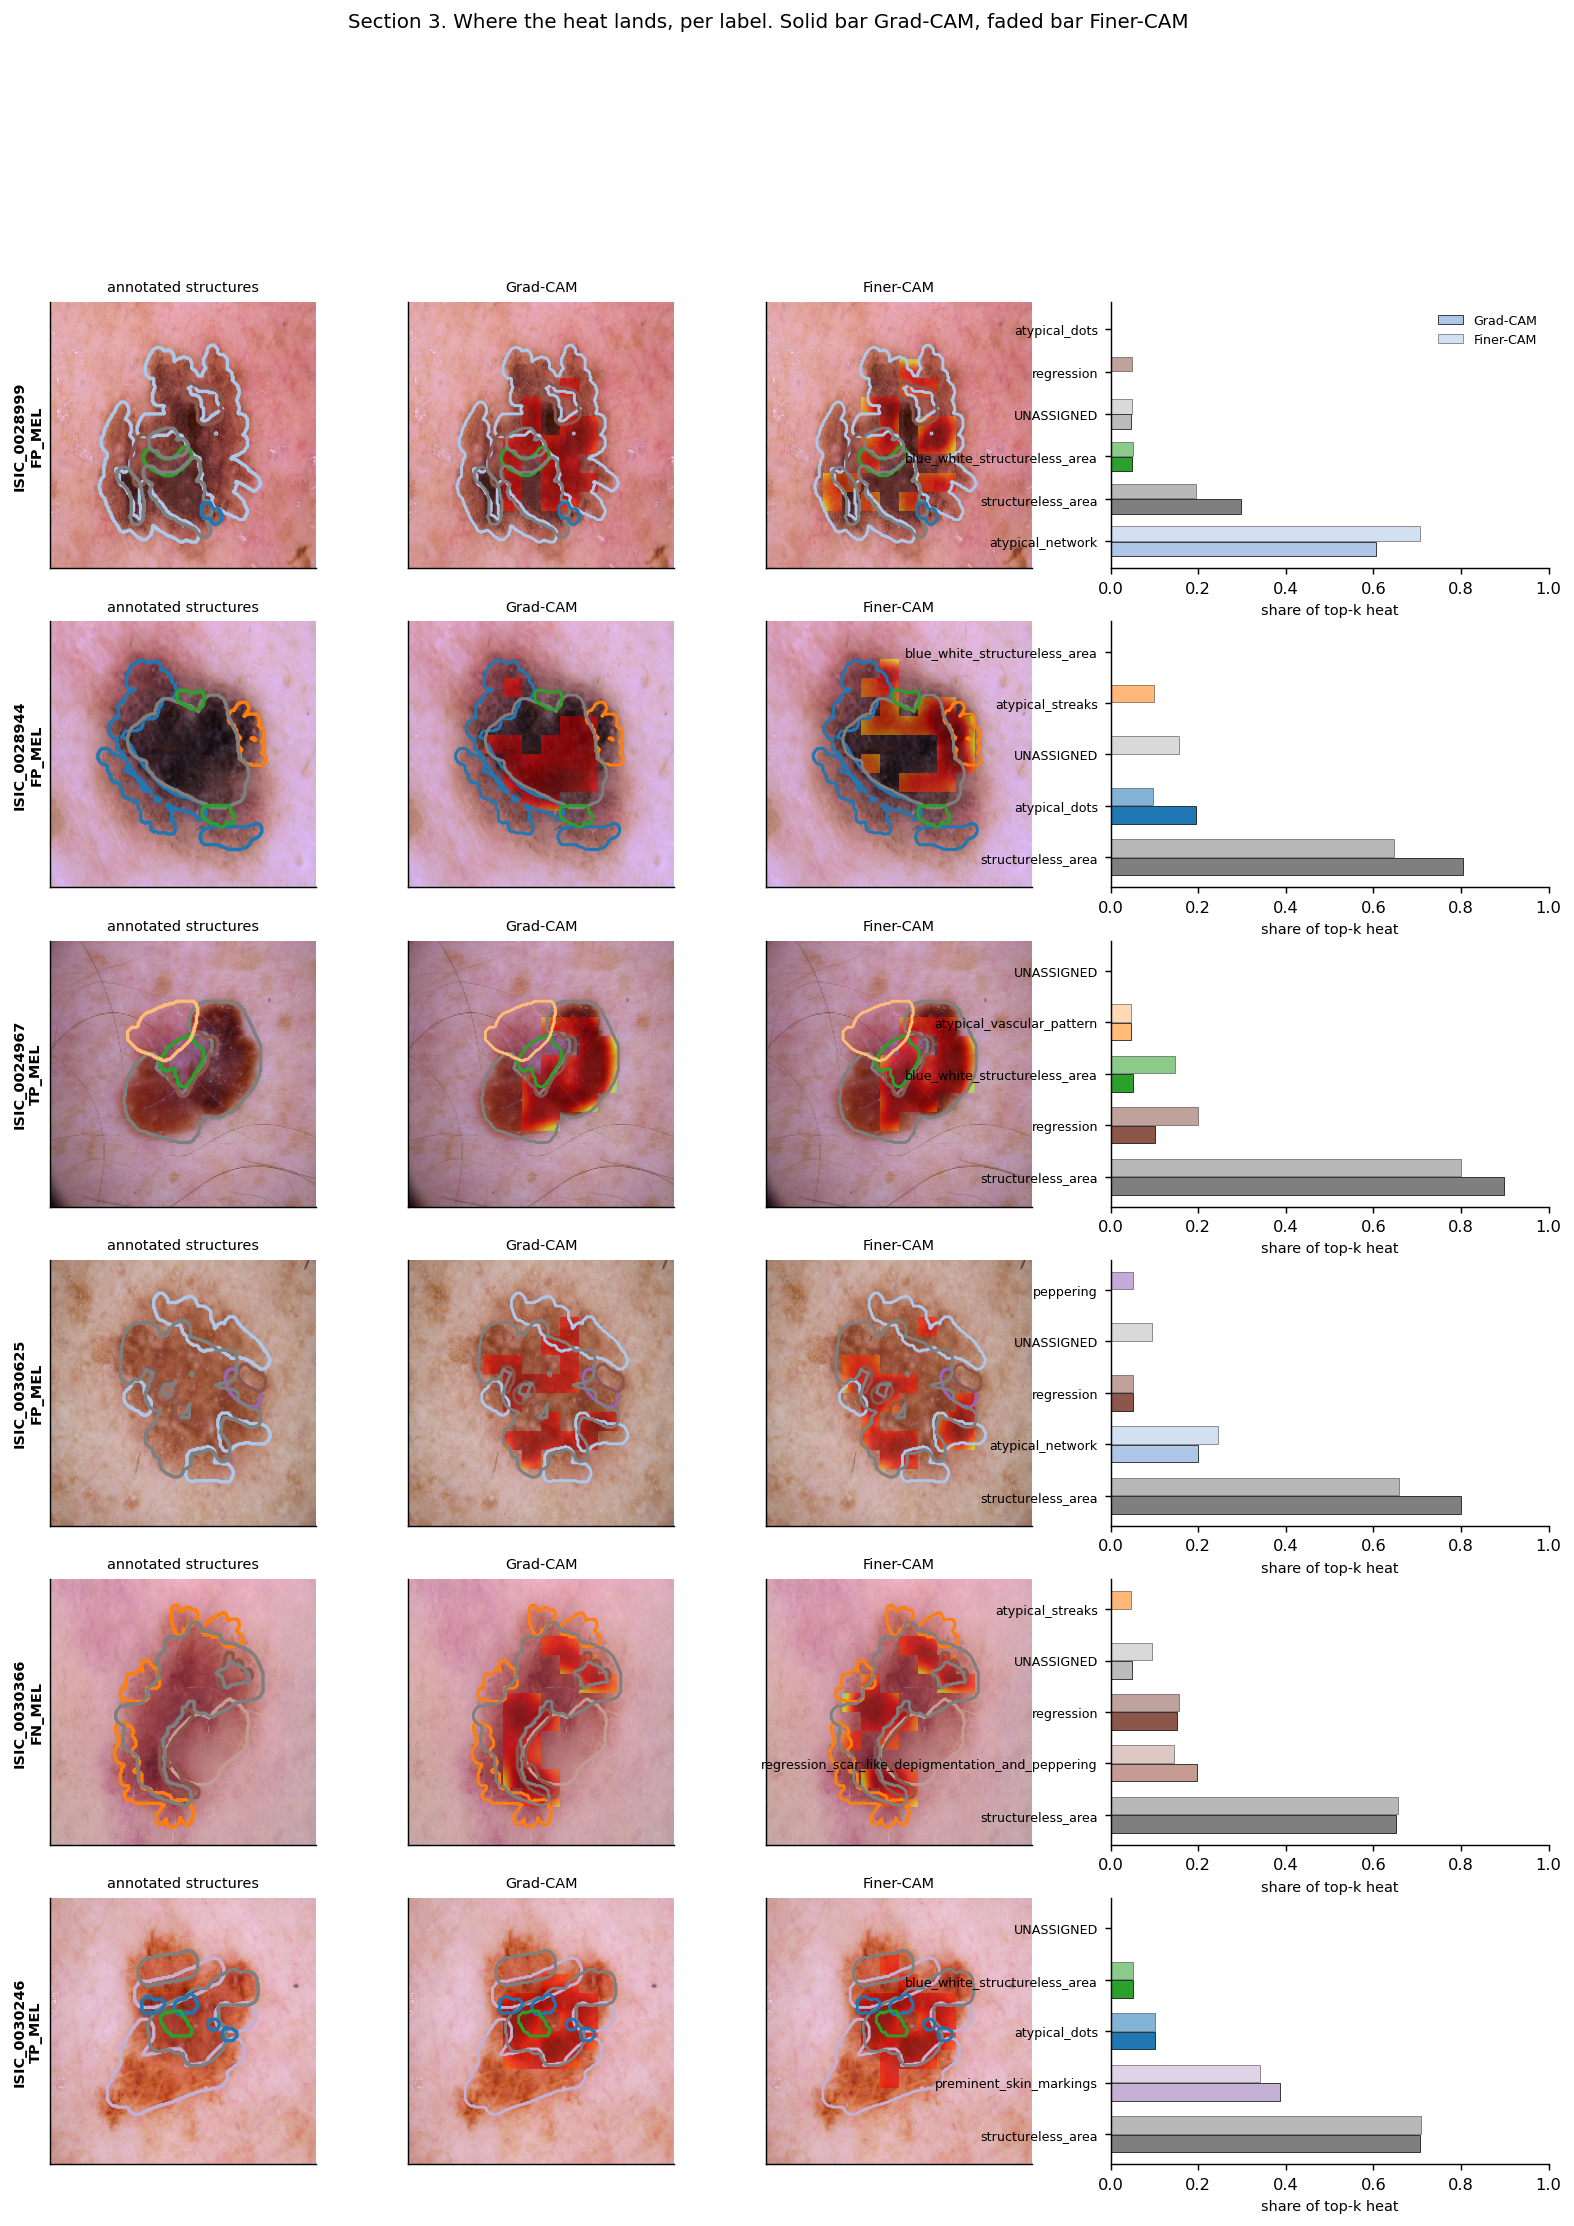

In [10]:
# =============================================================================
# FIGURE. Six cases, chosen for label diversity.
#
# Each row: image with colour coded outlines, Grad-CAM, Finer-CAM, and a
# bar chart attributing the heat across the labels present.
#
# This is the PDF to send before Friday.
# =============================================================================
labs = sorted(qcp.label.unique())
PAL = {l: plt.cm.tab20(i / 20) for i, l in enumerate(labs)}

cnt = (S3[S3.label != "UNASSIGNED"].groupby("image_id").label.nunique()
       .sort_values(ascending=False))
SHOW = list(cnt.head(6).index)

fig, axes = plt.subplots(len(SHOW), 4, figsize=(15, 3.1 * len(SHOW)),
                         gridspec_kw={"width_ratios": [1, 1, 1, 1.5]})
axes = np.atleast_2d(axes)

for i, iid in enumerate(SHOW):
    r = eval_df.set_index("image_id").loc[iid]
    rgb = transform_rgb(np.array(Image.open(
        (HAM_ROOT / str(r.image_rel_path)).resolve()).convert("RGB")), GEOMETRY)
    lg = label_grids(iid)
    p = pred[pred.image_id == iid].iloc[0]

    axes[i, 0].imshow(rgb)
    for lab in lg:
        m = np.array(Image.open(
            qcp[(qcp.Image_ID == iid) & (qcp.label == lab)]
            .mask_path.iloc[0]).convert("L")) > 127
        axes[i, 0].contour(transform_mask(m, GEOMETRY)[0].astype(float),
                           [0.5], colors=[PAL[lab]], linewidths=1.9)
    axes[i, 0].set_title("annotated structures", fontsize=8)

    for j, (kind, nm_) in enumerate(CAM_TYPES.items(), start=1):
        cam = load_act(iid, kind)
        axes[i, j].imshow(rgb)
        if cam is not None:
            c = norm01(cam)
            up = cv2.resize(c, (CROP_SIZE, CROP_SIZE),
                            interpolation=cv2.INTER_CUBIC)
            s_ = cv2.resize(topk_mask(c, TOP_K).astype(np.float32),
                            (CROP_SIZE, CROP_SIZE),
                            interpolation=cv2.INTER_NEAREST)
            axes[i, j].imshow(np.where(s_ > 0.5, up, np.nan), cmap="jet",
                              alpha=0.58, vmin=0, vmax=1)
        for lab in lg:
            m = np.array(Image.open(
                qcp[(qcp.Image_ID == iid) & (qcp.label == lab)]
                .mask_path.iloc[0]).convert("L")) > 127
            axes[i, j].contour(transform_mask(m, GEOMETRY)[0].astype(float),
                               [0.5], colors=[PAL[lab]], linewidths=1.6)
        axes[i, j].set_title(nm_, fontsize=8)

    for a in axes[i, :3]:
        a.set_xticks([]); a.set_yticks([])

    sub = S3[S3.image_id == iid]
    piv = (sub.pivot_table(index="label", columns="cam", values="share")
              .reindex(columns=["Grad-CAM", "Finer-CAM"]))
    piv = piv.reindex(sorted(piv.index, key=lambda l: -piv.loc[l].mean()))
    y = np.arange(len(piv))
    for k, cname in enumerate(piv.columns):
        axes[i, 3].barh(y + (k - 0.5) * 0.36, piv[cname], height=0.34,
                        color=[PAL.get(l, "#bbb") for l in piv.index],
                        alpha=1.0 if k == 0 else 0.55,
                        edgecolor="black", linewidth=0.4,
                        label=cname if i == 0 else None)
    axes[i, 3].set_yticks(y)
    axes[i, 3].set_yticklabels(piv.index, fontsize=7)
    axes[i, 3].set_xlabel("share of top-k heat", fontsize=8)
    axes[i, 3].set_xlim(0, 1)
    if i == 0:
        axes[i, 3].legend(fontsize=7, frameon=False)

    axes[i, 0].set_ylabel(f"{iid}\n{p.case_type}", fontsize=8,
                          fontweight="bold")

fig.suptitle("Section 3. Where the heat lands, per label. "
             "Solid bar Grad-CAM, faded bar Finer-CAM", fontsize=11, y=1.00)
fig.savefig(OUT / "s3_case_studies.png")
plt.show()

In [ ]:
# =============================================================================
# One page per image, all images with two or more labels. For Mauricio.
# =============================================================================
import matplotlib
from PIL import Image as PILImage

PAGES = OUT / "case_pages"
PAGES.mkdir(exist_ok=True)
_bk = matplotlib.get_backend()
matplotlib.use("Agg")

files = []
for iid in sorted(S3.image_id.unique()):
    r = eval_df.set_index("image_id").loc[iid]
    rgb = transform_rgb(np.array(Image.open(
        (HAM_ROOT / str(r.image_rel_path)).resolve()).convert("RGB")), GEOMETRY)
    lg = label_grids(iid)
    p = pred[pred.image_id == iid].iloc[0]

    f, ax = plt.subplots(1, 4, figsize=(15, 3.4),
                         gridspec_kw={"width_ratios": [1, 1, 1, 1.5]})
    ax[0].imshow(rgb)
    for lab in lg:
        m = np.array(Image.open(
            qcp[(qcp.Image_ID == iid) & (qcp.label == lab)]
            .mask_path.iloc[0]).convert("L")) > 127
        ax[0].contour(transform_mask(m, GEOMETRY)[0].astype(float), [0.5],
                      colors=[PAL[lab]], linewidths=1.9)
    ax[0].set_title("annotated structures", fontsize=9)

    for j, (kind, nm_) in enumerate(CAM_TYPES.items(), start=1):
        cam = load_act(iid, kind)
        ax[j].imshow(rgb)
        if cam is not None:
            c = norm01(cam)
            up = cv2.resize(c, (CROP_SIZE, CROP_SIZE),
                            interpolation=cv2.INTER_CUBIC)
            s_ = cv2.resize(topk_mask(c, TOP_K).astype(np.float32),
                            (CROP_SIZE, CROP_SIZE),
                            interpolation=cv2.INTER_NEAREST)
            ax[j].imshow(np.where(s_ > 0.5, up, np.nan), cmap="jet",
                         alpha=0.58, vmin=0, vmax=1)
        for lab in lg:
            m = np.array(Image.open(
                qcp[(qcp.Image_ID == iid) & (qcp.label == lab)]
                .mask_path.iloc[0]).convert("L")) > 127
            ax[j].contour(transform_mask(m, GEOMETRY)[0].astype(float), [0.5],
                          colors=[PAL[lab]], linewidths=1.6)
        ax[j].set_title(nm_, fontsize=9)

    for a in ax[:3]:
        a.set_xticks([]); a.set_yticks([])

    sub = S3[S3.image_id == iid]
    piv = (sub.pivot_table(index="label", columns="cam", values="share")
              .reindex(columns=["Grad-CAM", "Finer-CAM"]))
    piv = piv.reindex(sorted(piv.index, key=lambda l: -piv.loc[l].mean()))
    y = np.arange(len(piv))
    for k, cname in enumerate(piv.columns):
        ax[3].barh(y + (k - 0.5) * 0.36, piv[cname], height=0.34,
                   color=[PAL.get(l, "#bbb") for l in piv.index],
                   alpha=1.0 if k == 0 else 0.55,
                   edgecolor="black", linewidth=0.4, label=cname)
    ax[3].set_yticks(y)
    ax[3].set_yticklabels(piv.index, fontsize=8)
    ax[3].set_xlabel("share of top-k heat")
    ax[3].set_xlim(0, 1)
    ax[3].legend(fontsize=7, frameon=False)

    f.suptitle(f"{iid}   gt {p.gt_label}   pred {p.pred}   {p.case_type}   "
               f"conf {p.confidence:.2f}", fontsize=10, y=1.02)
    fp = PAGES / f"{iid}.png"
    f.savefig(fp, dpi=160, bbox_inches="tight", facecolor="white")
    plt.close(f)
    files.append(fp)

matplotlib.use(_bk)

imgs = [PILImage.open(p).convert("RGB") for p in files]
pdf = OUT / f"case_studies_{POOL_TAG}_ha5.pdf"
imgs[0].save(pdf, save_all=True, append_images=imgs[1:], resolution=150.0)
print(f"{len(imgs)} pages -> {pdf.relative_to(REPO)}")

33 pages -> results/followup/gap/case_studies_gap_ha5.pdf


---
## Section 4. Push alignment to failure

**Mauricio's request.** Alpha 5 is not far enough. Find where classification
performance is actually compromised, not just where alignment saturates.
He also asked whether F1 was used. It was not, only AUC. Both are reported
here.

**Two different populations, deliberately.**

| question | evaluated on |
|---|---|
| does classification break | **test split**, roughly 300 images |
| does the explanation keep improving | the 34 annotated images |
| does the class collapse deepen | test subsample, no annotations needed |

The 34 annotated images were curated for difficulty and reach only 0.588
accuracy. They cannot answer the first question.

**Three curves against alpha.**

| curve | measures |
|---|---|
| classification | AUC, F1, balanced accuracy on the test split |
| lesion alignment | CAM agreement with Tschandl lesion masks, what the loss optimised |
| class collapse | correlation between the two class maps |

Failure is defined as the first alpha where test AUC falls more than two
standard errors below its peak.

In [17]:
# =============================================================================
# SECTION 4a. Checkpoints and the test split.
#
# Supports both naming conventions.
#   checkpoint-best-gap-ha0p25.pth                         clean
#   checkpoint-best-foundation_gap_ha0.25_start0_...pth     raw from the sweep
# =============================================================================
import re
from sklearn.metrics import (roc_auc_score, f1_score, balanced_accuracy_score,
                             accuracy_score, recall_score)

ALPHA_DIR = REPO / "external" / "checkpoints_alpha"
CLEAN_CSV = HAM_ROOT / "mel_nv" / "ham_mel_nv_clean.csv"


def parse_alpha(name):
    if "dal" in name.lower():
        return None
    m = re.search(r"[-_]ha([\d]+(?:[p.]\d+)?)", name)
    return float(m.group(1).replace("p", ".")) if m else None


def parse_pool(name):
    m = re.search(r"[-_](gap|cls)[-_]", name)
    return m.group(1) if m else None


ck_alpha = {}
for d in [CKPT_DIR, ALPHA_DIR]:
    if not d.exists():
        continue
    for f in sorted(d.glob("*.pth")):
        a, p = parse_alpha(f.name), parse_pool(f.name)
        if a is None or p != POOL_TAG:
            continue
        ck_alpha.setdefault(a, f)

A_LIST = sorted(ck_alpha)
print(f"{len(A_LIST)} alpha checkpoints for {POOL_TAG}")
for a in A_LIST:
    print(f"  alpha {a:>6g}   {ck_alpha[a].name}")

if len(A_LIST) < 4:
    print(f"\nFewer than four. Expected the ablation in {ALPHA_DIR}")
    print("The curve will be sparse but the cells still run.")

# ---- test split ------------------------------------------------------------
clean = pd.read_csv(CLEAN_CSV)
clean["image_id"] = clean["image_id"].astype(str).str.strip()

LBL = ("binary_label" if "binary_label" in clean.columns
       else "label_2class" if "label_2class" in clean.columns else None)
if LBL is None:
    raise KeyError(f"no integer label column. found {clean.columns.tolist()}")

test = clean[clean.split == "test"].reset_index(drop=True)
print(f"\ntest split: {len(test)} images")
print(test.dx.value_counts().to_string())
print(f"label column '{LBL}', mapping "
      f"{test.groupby('dx')[LBL].first().to_dict()}")

MEL_LBL = int(test[test.dx == "mel"][LBL].iloc[0])
assert MEL_LBL == MEL_IDX, f"label mismatch, mel is {MEL_LBL} not {MEL_IDX}"

# ---- preload once, reused across every checkpoint --------------------------
print("\npreloading test images")
X_test, Y_test, ID_test = [], [], []
for _, r in test.iterrows():
    p = (HAM_ROOT / str(r.image_rel_path)).resolve()
    if not p.exists():
        continue
    X_test.append(PREPROCESS(Image.open(p).convert("RGB")))
    Y_test.append(int(r[LBL]))
    ID_test.append(r.image_id)

X_test = torch.stack(X_test)
Y_test = np.array(Y_test)
print(f"loaded {len(X_test)}  MEL {int((Y_test == MEL_IDX).sum())}  "
      f"NV {int((Y_test == NV_IDX).sum())}")

# subsample for the gradient based metrics
rng = np.random.default_rng(0)
SUB_N = min(60, len(ID_test))
SUB = rng.choice(len(ID_test), SUB_N, replace=False)
print(f"CAM metrics on a {SUB_N} image subsample")

10 alpha checkpoints for gap
  alpha      0   checkpoint-best-gap-ha0.pth
  alpha    0.1   checkpoint-best-gap-ha0p1.pth
  alpha   0.25   checkpoint-best-gap-ha0p25.pth
  alpha    0.5   checkpoint-best-gap-ha0p5.pth
  alpha      1   checkpoint-best-gap-ha1.pth
  alpha      3   checkpoint-best-gap-ha3.pth
  alpha      5   checkpoint-best-gap-ha5.pth
  alpha      7   checkpoint-best-gap-ha7.pth
  alpha     11   checkpoint-best-gap-ha11.pth
  alpha     17   checkpoint-best-gap-ha17.pth

test split: 1021 images
dx
nv     951
mel     70
label column 'binary_label', mapping {'mel': 0, 'nv': 1}

preloading test images
loaded 1021  MEL 70  NV 951
CAM metrics on a 60 image subsample


In [18]:
# =============================================================================
# SECTION 4b. Classification on the test split. No gradients, batched.
#
# READ  AUC and F1 are what Mauricio asked for. Balanced accuracy is
#       included since the test split may not be perfectly balanced.
#       Failure is the first alpha where AUC drops more than two standard
#       errors below the peak.
# =============================================================================
def boot_auc_se(y, p, n=1000, seed=0):
    rng = np.random.default_rng(seed)
    v = []
    for _ in range(n):
        i = rng.choice(len(y), len(y), replace=True)
        if len(np.unique(y[i])) < 2:
            continue
        v.append(roc_auc_score(y[i], p[i]))
    return float(np.std(v))


rows = []
for a in A_LIST:
    ck = ck_alpha[a]
    raw, _ = extract_checkpoint_state_dict(
        torch.load(ck, map_location="cpu", weights_only=False))
    st = remap_official_finetune_checkpoint_keys(raw)
    m = build_panderm_model(num_classes=2,
                            variant=infer_panderm_variant_from_state_dict(st),
                            use_mean_pooling=(POOLING == "mean"))
    miss, unexp = m.load_state_dict(st, strict=False)
    bad = [k for k in list(miss) + list(unexp)
           if k.startswith(("norm.", "fc_norm.", "head."))]
    if bad:
        print(f"  alpha {a:g}: SKIP, critical keys {bad}")
        continue
    m.to(DEVICE).eval()

    probs = []
    with torch.no_grad():
        for i in range(0, len(X_test), 32):
            out = m(X_test[i:i + 32].to(DEVICE))
            lg = out["logits"] if isinstance(out, dict) else (
                out[0] if isinstance(out, (tuple, list)) else out)
            probs.append(torch.softmax(lg, 1).cpu().numpy())
    probs = np.vstack(probs)
    pred = probs.argmax(1)

    y_mel = (Y_test == MEL_IDX).astype(int)
    p_mel = probs[:, MEL_IDX]

    rows.append({
        "alpha": a, "n": len(Y_test),
        "auc": roc_auc_score(y_mel, p_mel),
        "auc_se": boot_auc_se(y_mel, p_mel),
        "f1_macro": f1_score(Y_test, pred, average="macro"),
        "f1_mel": f1_score(Y_test, pred, pos_label=MEL_IDX),
        "bacc": balanced_accuracy_score(Y_test, pred),
        "acc": accuracy_score(Y_test, pred),
        "recall_mel": recall_score(Y_test, pred, pos_label=MEL_IDX),
        "recall_nv": recall_score(Y_test, pred, pos_label=NV_IDX),
    })
    del m
    if DEVICE == "mps":
        torch.mps.empty_cache()
    print(f"  alpha {a:>6g}   AUC {rows[-1]['auc']:.4f}   "
          f"F1 {rows[-1]['f1_macro']:.4f}   bacc {rows[-1]['bacc']:.4f}")

CLS = pd.DataFrame(rows).sort_values("alpha")
CLS.to_csv(OUT / "s4_classification.csv", index=False)

print("\n" + "=" * 86)
print(f"SECTION 4b  classification on the test split, n={len(Y_test)}, "
      f"{POOL_TAG.upper()}")
print("=" * 86)
print(CLS[["alpha", "auc", "auc_se", "f1_macro", "f1_mel", "bacc",
           "recall_mel", "recall_nv"]].round(4).to_string(index=False))

peak = CLS.loc[CLS.auc.idxmax()]
thr = peak.auc - 2 * peak.auc_se
fail = CLS[(CLS.alpha > peak.alpha) & (CLS.auc < thr)]

print(f"\npeak AUC {peak.auc:.4f} at alpha {peak.alpha:g}, "
      f"bootstrap SE {peak.auc_se:.4f}")
print(f"failure threshold, peak minus two SE: {thr:.4f}")
if len(fail):
    f0 = fail.iloc[0]
    print(f"\nFAILURE at alpha {f0.alpha:g}")
    print(f"  AUC {f0.auc:.4f}, which is {peak.auc - f0.auc:.4f} below peak")
    print(f"  F1  {f0.f1_macro:.4f} versus {peak.f1_macro:.4f} at peak")
else:
    print(f"\nNO FAILURE within the range tested, up to alpha "
          f"{CLS.alpha.max():g}")
    print(f"  largest drop from peak: "
          f"{peak.auc - CLS[CLS.alpha > peak.alpha].auc.min():.4f}")
    print("  alignment can be pushed further without breaking classification")

  alpha      0   AUC 0.9749   F1 0.7020   bacc 0.9111
  alpha    0.1   AUC 0.9742   F1 0.7020   bacc 0.9111
  alpha   0.25   AUC 0.9733   F1 0.6997   bacc 0.9100
  alpha    0.5   AUC 0.9721   F1 0.7020   bacc 0.9111
  alpha      1   AUC 0.9701   F1 0.6985   bacc 0.9095
  alpha      3   AUC 0.9621   F1 0.6869   bacc 0.8926
  alpha      5   AUC 0.9623   F1 0.6914   bacc 0.8947
  alpha      7   AUC 0.9536   F1 0.6921   bacc 0.9008
  alpha     11   AUC 0.9475   F1 0.6843   bacc 0.8971
  alpha     17   AUC 0.9382   F1 0.6785   bacc 0.8828

SECTION 4b  classification on the test split, n=1021, GAP
 alpha    auc  auc_se  f1_macro  f1_mel   bacc  recall_mel  recall_nv
  0.00 0.9749  0.0059    0.7020  0.4857 0.9111      0.9714     0.8507
  0.10 0.9742  0.0061    0.7020  0.4857 0.9111      0.9714     0.8507
  0.25 0.9733  0.0062    0.6997  0.4823 0.9100      0.9714     0.8486
  0.50 0.9721  0.0064    0.7020  0.4857 0.9111      0.9714     0.8507
  1.00 0.9701  0.0067    0.6985  0.4806 0.9095     

In [19]:
# =============================================================================
# SECTION 4c. Does the explanation keep improving, and does the collapse
# keep deepening, over the same alpha range.
#
#   lesion alignment   CAM against the Tschandl lesion mask on a test
#                      subsample. This is what the loss optimised.
#   human alignment    CAM against the clinician MEL union, the 34 images.
#   class collapse     correlation between the two class maps.
#
# READ  if classification holds while lesion alignment saturates and the
#       collapse deepens, the cost of excessive alpha is explanatory, not
#       predictive.
# =============================================================================
LES_TEST = {}
for i in SUB:
    r = test[test.image_id == ID_test[i]].iloc[0]
    p = (HAM_ROOT / str(r.mask_rel_path)).resolve()
    if p.exists():
        m = np.array(Image.open(p).convert("L")) > 127
        LES_TEST[ID_test[i]] = mask_to_cam_grid_geom(m, GEOMETRY) >= 0.5

print(f"lesion masks for {len(LES_TEST)} of {len(SUB)} subsample images")

# clinician MEL unions, the 34 images
HUM = {i: mel_union_grid(i) for i in eval_df.image_id}
HUM = {k: v for k, v in HUM.items() if v is not None
       and 0 < v.sum() < v.size}
print(f"clinician MEL unions for {len(HUM)} images")

rows = []
for a in A_LIST:
    ck = ck_alpha[a]
    raw, _ = extract_checkpoint_state_dict(
        torch.load(ck, map_location="cpu", weights_only=False))
    st = remap_official_finetune_checkpoint_keys(raw)
    m = build_panderm_model(num_classes=2,
                            variant=infer_panderm_variant_from_state_dict(st),
                            use_mean_pooling=(POOLING == "mean"))
    if [k for k in list(m.load_state_dict(st, strict=False)[0])
            if k.startswith(("norm.", "fc_norm.", "head."))]:
        continue
    m.to(DEVICE).eval()
    for q in m.parameters():
        q.requires_grad_(True)

    # lesion alignment and collapse, test subsample
    les_auc, corr, ptg = [], [], []
    for i in SUB:
        iid = ID_test[i]
        if iid not in LES_TEST:
            continue
        cm, cn = class_cams(m, X_test[i:i + 1].to(DEVICE))
        r_ = test[test.image_id == iid].iloc[0]
        tgt = cm if int(r_[LBL]) == MEL_IDX else cn
        L = LES_TEST[iid]
        if 0 < L.sum() < L.size:
            les_auc.append(roc_auc_score(L.ravel(), norm01(tgt).ravel()))
            ptg.append(float(L[np.unravel_index(np.argmax(tgt), tgt.shape)]))
        corr.append(float(np.corrcoef(norm01(cm).ravel(),
                                      norm01(cn).ravel())[0, 1]))

    # human alignment, the 34 annotated images
    hum_auc = []
    for _, r_ in eval_df.iterrows():
        if r_.image_id not in HUM:
            continue
        cm, cn = class_cams(m, load_tensor(r_.image_rel_path))
        tgt = cm if r_.gt_label == "MEL" else cn
        hum_auc.append(roc_auc_score(HUM[r_.image_id].ravel(),
                                     norm01(tgt).ravel()))

    rows.append({
        "alpha": a,
        "lesion_auc": float(np.median(les_auc)) if les_auc else np.nan,
        "lesion_pointing": float(np.mean(ptg)) if ptg else np.nan,
        "human_auc": float(np.median(hum_auc)) if hum_auc else np.nan,
        "class_corr": float(np.median(corr)),
        "n_test": len(les_auc), "n_human": len(hum_auc),
    })
    del m
    if DEVICE == "mps":
        torch.mps.empty_cache()
    print(f"  alpha {a:>6g}   lesion {rows[-1]['lesion_auc']:.3f}   "
          f"human {rows[-1]['human_auc']:.3f}   "
          f"collapse {rows[-1]['class_corr']:+.3f}")

EXP = pd.DataFrame(rows).sort_values("alpha")
S4 = CLS.merge(EXP, on="alpha", how="outer").sort_values("alpha")
S4["pooling"] = POOL_TAG
S4.to_csv(OUT / "s4_alpha_failure.csv", index=False)

print("\n" + "=" * 96)
print(f"SECTION 4  full ablation, {POOL_TAG.upper()}")
print("=" * 96)
print(S4[["alpha", "auc", "f1_macro", "bacc", "lesion_auc",
          "lesion_pointing", "human_auc", "class_corr"]]
      .round(4).to_string(index=False))

lesion masks for 60 of 60 subsample images
clinician MEL unions for 31 images
  alpha      0   lesion 0.417   human 0.576   collapse -0.243
  alpha    0.1   lesion 0.980   human 0.948   collapse +0.854
  alpha   0.25   lesion 0.984   human 0.947   collapse +0.926
  alpha    0.5   lesion 0.986   human 0.961   collapse +0.947
  alpha      1   lesion 0.988   human 0.963   collapse +0.963
  alpha      3   lesion 0.988   human 0.964   collapse +0.967
  alpha      5   lesion 0.983   human 0.965   collapse +0.970
  alpha      7   lesion 0.988   human 0.962   collapse +0.980
  alpha     11   lesion 0.988   human 0.963   collapse +0.987
  alpha     17   lesion 0.989   human 0.964   collapse +0.991

SECTION 4  full ablation, GAP
 alpha    auc  f1_macro   bacc  lesion_auc  lesion_pointing  human_auc  class_corr
  0.00 0.9749    0.7020 0.9111      0.4174           0.1833     0.5758     -0.2431
  0.10 0.9742    0.7020 0.9111      0.9802           0.9667     0.9476      0.8544
  0.25 0.9733    0.699

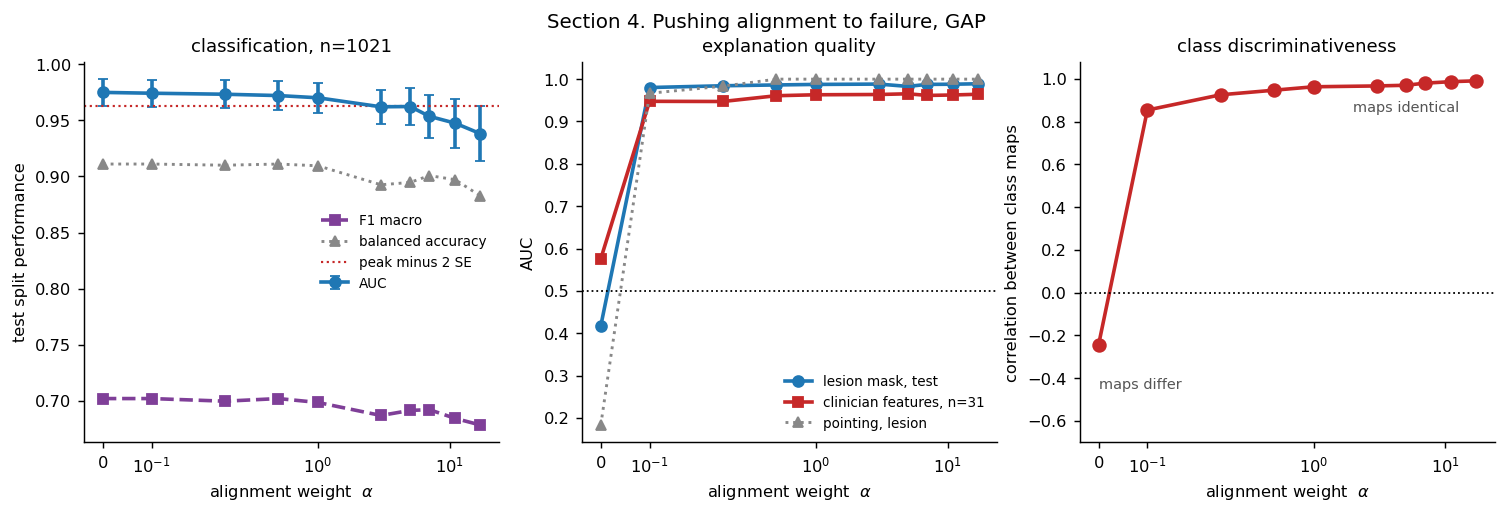

In [20]:
# =============================================================================
# FIGURE. Where does alignment break what.
#
# READ  left    classification. Does it hold across the range.
#       middle  explanation quality. Where does it saturate.
#       right   class collapse. Where does it complete.
#
# The answer Mauricio wants is the alpha where the left panel drops.
# The answer that matters for the thesis is that the middle and right
# panels finish long before the left one moves.
# =============================================================================
fig, ax = plt.subplots(1, 3, figsize=(14, 3.8))
logx = S4.alpha.max() / max(S4[S4.alpha > 0].alpha.min(), 0.01) > 20

for a_ in ax:
    if logx:
        a_.set_xscale("symlog", linthresh=0.3)
    a_.set_xlabel(r"alignment weight  $\alpha$")

ax[0].errorbar(S4.alpha, S4.auc, yerr=2 * S4.auc_se, fmt="o-",
               color=C_ATTN, lw=2, ms=6, capsize=3, label="AUC")
ax[0].plot(S4.alpha, S4.f1_macro, "s--", color=C_ACT, lw=2, ms=6,
           label="F1 macro")
ax[0].plot(S4.alpha, S4.bacc, "^:", color="#888", lw=1.6, ms=6,
           label="balanced accuracy")
pk = S4.loc[S4.auc.idxmax()]
ax[0].axhline(pk.auc - 2 * pk.auc_se, color=C_MEL, ls=":", lw=1.2,
              label="peak minus 2 SE")
ax[0].set_ylabel("test split performance")
ax[0].set_title(f"classification, n={int(S4.n.iloc[0])}", fontsize=10)
ax[0].legend(frameon=False, fontsize=7.5)

ax[1].plot(S4.alpha, S4.lesion_auc, "o-", color=C_ATTN, lw=2, ms=6,
           label="lesion mask, test")
ax[1].plot(S4.alpha, S4.human_auc, "s-", color=C_MEL, lw=2, ms=6,
           label="clinician features, n=31")
ax[1].plot(S4.alpha, S4.lesion_pointing, "^:", color="#888", lw=1.6, ms=6,
           label="pointing, lesion")
ax[1].axhline(0.5, color="k", ls=":", lw=1)
ax[1].set_ylabel("AUC")
ax[1].set_title("explanation quality", fontsize=10)
ax[1].legend(frameon=False, fontsize=7.5, loc="lower right")

ax[2].plot(S4.alpha, S4.class_corr, "o-", color=C_MEL, lw=2, ms=7)
ax[2].axhline(0, color="k", ls=":", lw=1)
ax[2].set_ylim(-0.7, 1.08)
ax[2].set_ylabel("correlation between class maps")
ax[2].set_title("class discriminativeness", fontsize=10)
ax[2].annotate("maps differ", (S4.alpha.min(), -0.45), fontsize=8,
               color="#555")
ax[2].annotate("maps identical", (S4.alpha.median(), 0.85), fontsize=8,
               color="#555")

fig.suptitle(f"Section 4. Pushing alignment to failure, {POOL_TAG.upper()}",
             fontsize=11)
fig.savefig(OUT / "s4_failure_curve.png")
plt.show()

In [21]:
# =============================================================================
# Where each thing breaks, and the draft text.
# =============================================================================
pk = S4.loc[S4.auc.idxmax()]
thr = pk.auc - 2 * pk.auc_se


def saturation(col, frac=0.95):
    """First alpha reaching frac of the total gain on that column."""
    s = S4.dropna(subset=[col]).sort_values("alpha")
    if len(s) < 3:
        return None
    lo, hi = s[col].iloc[0], s[col].max()
    if hi - lo < 1e-6:
        return None
    t = lo + frac * (hi - lo)
    ok = s[s[col] >= t]
    return float(ok.alpha.iloc[0]) if len(ok) else None


sat_les = saturation("lesion_auc")
if sat_les == S4[S4.alpha > 0].alpha.min():
    print(f"  WARNING: saturation is at the smallest nonzero alpha tested. "
          f"The true saturation point is below {sat_les:g} and unresolved.")
sat_hum = saturation("human_auc")
col_a = S4[S4.class_corr > 0.9].alpha.min() if (S4.class_corr > 0.9).any() else None
fail = S4[(S4.alpha > pk.alpha) & (S4.auc < thr)]

print("=" * 78)
print("WHERE EACH THING BREAKS")
print("=" * 78)
print(f"  peak classification AUC     alpha {pk.alpha:g}   "
      f"AUC {pk.auc:.4f}   F1 {pk.f1_macro:.4f}")
print(f"  lesion alignment saturates  alpha {sat_les}")
print(f"  human alignment saturates   alpha {sat_hum}")
print(f"  class collapse complete     alpha {col_a}   (correlation above 0.9)")
print(f"  classification failure      alpha "
      f"{fail.alpha.iloc[0] if len(fail) else 'none in range'}")

print("\n" + "-" * 78)
print("DRAFT TEXT\n")
print(f"""The alignment weight was swept across {len(S4)} values from
{S4.alpha.min():g} to {S4.alpha.max():g}. Classification was evaluated on the
held out test split of {int(S4.n.iloc[0])} images, explanation quality on the
same split against lesion masks and on the {int(S4.n_human.max())} annotated
images against clinician features.""")

if len(fail):
    f0 = fail.iloc[0]
    print(f"""
Classification degrades from alpha = {f0.alpha:g}, where test AUC falls to
{f0.auc:.4f} against a peak of {pk.auc:.4f} at alpha = {pk.alpha:g}, a drop of
more than two bootstrap standard errors. Macro F1 falls from {pk.f1_macro:.4f}
to {f0.f1_macro:.4f} over the same interval.""")
else:
    print(f"""
Classification does not degrade within the range tested. Test AUC varies
between {S4.auc.min():.4f} and {S4.auc.max():.4f} across the full sweep, and no
value falls more than two bootstrap standard errors below the peak. The
alignment term can therefore be weighted far beyond the point of
explanatory saturation without measurable cost to prediction.""")

print(f"""
The three curves decouple. Lesion alignment saturates by alpha
{sat_les}, class discriminativeness has collapsed by alpha {col_a}, and
classification is unaffected across the entire range. The cost of excessive
alignment is therefore borne by the explanation rather than by the
prediction.

The operating point used in the main analysis, alpha = 5, was fixed before
this ablation.""")

WHERE EACH THING BREAKS
  peak classification AUC     alpha 0   AUC 0.9749   F1 0.7020
  lesion alignment saturates  alpha 0.1
  human alignment saturates   alpha 0.1
  class collapse complete     alpha 0.25   (correlation above 0.9)
  classification failure      alpha 3.0

------------------------------------------------------------------------------
DRAFT TEXT

The alignment weight was swept across 10 values from
0 to 17. Classification was evaluated on the
held out test split of 1021 images, explanation quality on the
same split against lesion masks and on the 31 annotated
images against clinician features.

Classification degrades from alpha = 3, where test AUC falls to
0.9621 against a peak of 0.9749 at alpha = 0, a drop of
more than two bootstrap standard errors. Macro F1 falls from 0.7020
to 0.6869 over the same interval.

The three curves decouple. Lesion alignment saturates by alpha
0.1, class discriminativeness has collapsed by alpha 0.25, and
classification is unaffected acr